<a href="https://colab.research.google.com/github/yohperez/EjemplosMates/blob/main/zanahorias_concurso_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🥕 Concurso de Zanahorias — Análisis Estadístico
### Un grupo de agricultores mide sus zanahorias. ¿Quién tiene el cultivo más uniforme?
---

## 📦 Celda 1 — Librerías

In [1]:
import math
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from collections import Counter

print("✅ Librerías cargadas correctamente.")

✅ Librerías cargadas correctamente.


## 🥕 Celda 2 — Datos del concurso
Los 12 pesos (en gramos) de las zanahorias participantes:

In [2]:
# Pesos en gramos de las 12 zanahorias
zanahorias = [300, 280, 290, 310, 275, 290, 295, 315, 290, 280, 310, 305]

print(f"Total de zanahorias: {len(zanahorias)}")
print(f"Pesos: {zanahorias}")

Total de zanahorias: 12
Pesos: [300, 280, 290, 310, 275, 290, 295, 315, 290, 280, 310, 305]


## 🔧 Celda 3 — Funciones estadísticas
Definimos todas las funciones necesarias para el análisis:

In [3]:
def calcular_media(datos):
    """Promedio de los valores."""
    return sum(datos) / len(datos)

def calcular_mediana(datos):
    """Valor central cuando los datos están ordenados."""
    s = sorted(datos)
    n = len(s)
    m = n // 2
    return (s[m-1] + s[m]) / 2 if n % 2 == 0 else float(s[m])

def calcular_moda(datos):
    """Valor(es) que aparecen con mayor frecuencia."""
    conteo = Counter(datos)
    max_freq = max(conteo.values())
    modas = sorted(k for k, v in conteo.items() if v == max_freq)
    return modas, max_freq

def calcular_std(datos):
    """Desviación estándar poblacional."""
    mu = calcular_media(datos)
    return math.sqrt(sum((x - mu) ** 2 for x in datos) / len(datos))

def barra_ascii(valor, minimo, maximo, ancho=25):
    """Genera una barra visual ASCII proporcional al valor."""
    p = (valor - minimo) / (maximo - minimo) if maximo != minimo else 1
    llena = int(p * ancho)
    return "█" * llena + "░" * (ancho - llena)

def calificar_uniformidad(cv):
    """Clasifica la uniformidad según el coeficiente de variación."""
    if cv < 5:    return "🌟 EXCELENTE — Cultivo súper uniforme"
    elif cv < 10: return "✅ BUENO — Bastante parejo"
    elif cv < 20: return "⚠️  REGULAR — Hay variación notable"
    else:         return "❌ IRREGULAR — Cultivo muy variable"

print("✅ Funciones definidas.")

✅ Funciones definidas.


## 📊 Celda 4 — Cálculo y resultados estadísticos

In [4]:
# ── Calcular estadísticas ──
mn, mx    = min(zanahorias), max(zanahorias)
media     = calcular_media(zanahorias)
mediana   = calcular_mediana(zanahorias)
modas, freq = calcular_moda(zanahorias)
std       = calcular_std(zanahorias)
cv        = (std / media) * 100      # Coeficiente de variación

# ── Mostrar tabla ASCII ──
print("=" * 56)
print("   ANÁLISIS DEL CONCURSO DE ZANAHORIAS")
print("=" * 56)

print(f"\n  Pesos registrados ({len(zanahorias)} zanahorias):\n")
for i, p in enumerate(zanahorias, 1):
    indicador = " <- [MAX]" if p == mx else (" <- [min]" if p == mn else "")
    print(f"   #{i:>2}  {p:>4}g  {barra_ascii(p, mn, mx)}{indicador}")

print("\n" + "-" * 56)
print("  ESTADÍSTICAS DEL CULTIVO")
print("-" * 56)
print(f"  📌 Media (promedio)     : {media:.2f} g")
print(f"  📌 Mediana              : {mediana:.1f} g")
mstr = ", ".join(f"{m}g" for m in modas)
print(f"  📌 Moda                 : {mstr}  (aparece {freq}x)")
print(f"  📌 Desviación estándar  : {std:.2f} g")
print(f"  📌 Mínimo / Máximo      : {mn}g / {mx}g")
print(f"  📌 Rango                : {mx - mn}g")
print(f"  📌 Coef. de variación   : {cv:.1f}%")

print("\n" + "-" * 56)
print("  🏆 VEREDICTO DEL JURADO")
print("-" * 56)
print(f"  {calificar_uniformidad(cv)}")
print(f"\n  La zanahoria mas pesada : {mx}g  [MAYOR]")
print(f"  La zanahoria mas ligera : {mn}g  [menor]")
print("=" * 56)

   ANÁLISIS DEL CONCURSO DE ZANAHORIAS

  Pesos registrados (12 zanahorias):

   # 1   300g  ███████████████░░░░░░░░░░
   # 2   280g  ███░░░░░░░░░░░░░░░░░░░░░░
   # 3   290g  █████████░░░░░░░░░░░░░░░░
   # 4   310g  █████████████████████░░░░
   # 5   275g  ░░░░░░░░░░░░░░░░░░░░░░░░░ <- [min]
   # 6   290g  █████████░░░░░░░░░░░░░░░░
   # 7   295g  ████████████░░░░░░░░░░░░░
   # 8   315g  █████████████████████████ <- [MAX]
   # 9   290g  █████████░░░░░░░░░░░░░░░░
   #10   280g  ███░░░░░░░░░░░░░░░░░░░░░░
   #11   310g  █████████████████████░░░░
   #12   305g  ██████████████████░░░░░░░

--------------------------------------------------------
  ESTADÍSTICAS DEL CULTIVO
--------------------------------------------------------
  📌 Media (promedio)     : 295.00 g
  📌 Mediana              : 292.5 g
  📌 Moda                 : 290g  (aparece 3x)
  📌 Desviación estándar  : 12.58 g
  📌 Mínimo / Máximo      : 275g / 315g
  📌 Rango                : 40g
  📌 Coef. de variación   : 4.3%

---------------

## 📈 Celda 5 — Visualización (Bonus Extra 1)
Dos paneles: barras individuales por zanahoria e histograma con curva normal.

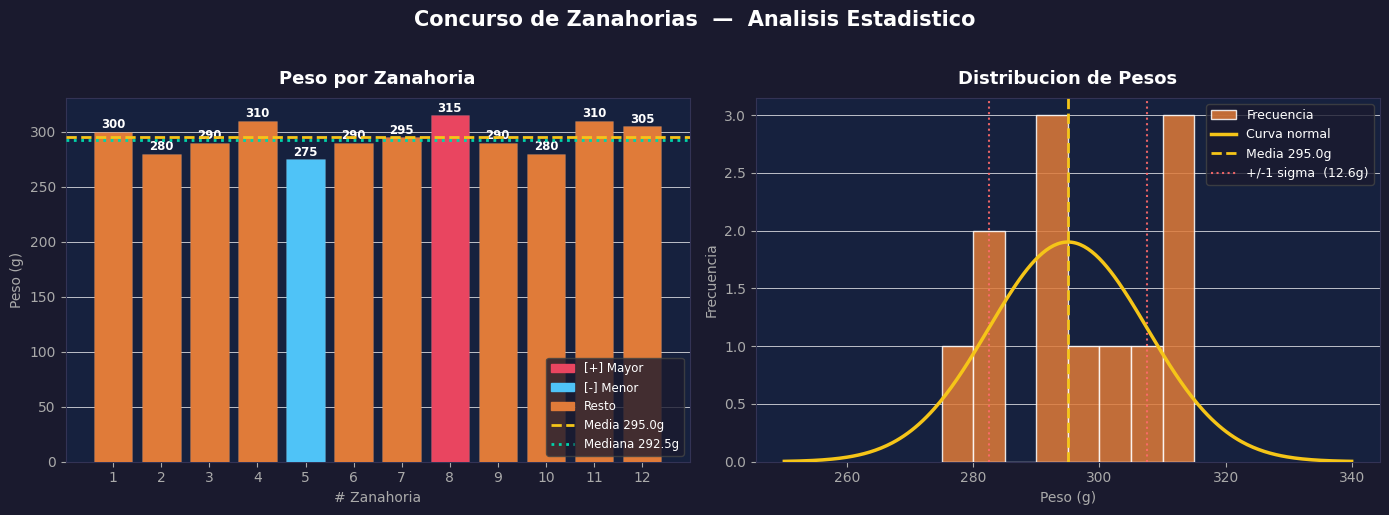


📁 Gráfica guardada como 'grafica_zanahorias.png'


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor("#1a1a2e")

# Colores: rojo = mayor, azul = menor, naranja = resto
colores = ["#e94560" if x == mx else "#4fc3f7" if x == mn else "#e07b39"
           for x in zanahorias]

# ─── Panel 1: barras individuales ───
ax1 = axes[0]
ax1.set_facecolor("#16213e")

barras = ax1.bar(range(1, len(zanahorias) + 1), zanahorias,
                 color=colores, edgecolor="#ffffff22", linewidth=0.5, zorder=3)

ax1.axhline(media,   color="#f5c518", lw=2, ls="--", label=f"Media {media:.1f}g", zorder=4)
ax1.axhline(mediana, color="#00d4aa", lw=2, ls=":",  label=f"Mediana {mediana:.1f}g", zorder=4)

for bar, val in zip(barras, zanahorias):
    ax1.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.5, str(val),
             ha="center", va="bottom", color="white", fontsize=8.5, fontweight="bold")

parches = [
    mpatches.Patch(color="#e94560", label="[+] Mayor"),
    mpatches.Patch(color="#4fc3f7", label="[-] Menor"),
    mpatches.Patch(color="#e07b39", label="Resto"),
    plt.Line2D([0],[0], color="#f5c518", lw=2, ls="--", label=f"Media {media:.1f}g"),
    plt.Line2D([0],[0], color="#00d4aa", lw=2, ls=":",  label=f"Mediana {mediana:.1f}g"),
]
ax1.legend(handles=parches, facecolor="#1a1a2e", edgecolor="#444",
           labelcolor="white", fontsize=8.5, loc="lower right")
ax1.set_title("Peso por Zanahoria", color="white", fontsize=13, fontweight="bold", pad=10)
ax1.set_xlabel("# Zanahoria", color="#aaaaaa", fontsize=10)
ax1.set_ylabel("Peso (g)", color="#aaaaaa", fontsize=10)
ax1.tick_params(colors="#aaaaaa")
ax1.set_xticks(range(1, len(zanahorias) + 1))
ax1.grid(axis="y", color="#ffffff11", linewidth=0.5, zorder=0)
for sp in ax1.spines.values(): sp.set_edgecolor("#333355")

# ─── Panel 2: histograma + curva normal ───
ax2 = axes[1]
ax2.set_facecolor("#16213e")

n_hist, bins, _ = ax2.hist(zanahorias, bins=8, color="#e07b39",
                            edgecolor="#ffffff44", alpha=0.85, label="Frecuencia", zorder=3)

x = np.linspace(mn - 25, mx + 25, 300)
y = (1 / (std * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - media) / std) ** 2)
ax2.plot(x, y * len(zanahorias) * (bins[1] - bins[0]),
         color="#f5c518", lw=2.5, label="Curva normal", zorder=5)

ax2.axvline(media,       color="#f5c518", lw=2,   ls="--", label=f"Media {media:.1f}g", zorder=4)
ax2.axvline(media - std, color="#ff6b6b", lw=1.5, ls=":",  alpha=0.9, zorder=4)
ax2.axvline(media + std, color="#ff6b6b", lw=1.5, ls=":",  alpha=0.9,
            label=f"+/-1 sigma  ({std:.1f}g)", zorder=4)

ax2.set_title("Distribucion de Pesos", color="white", fontsize=13, fontweight="bold", pad=10)
ax2.set_xlabel("Peso (g)", color="#aaaaaa", fontsize=10)
ax2.set_ylabel("Frecuencia", color="#aaaaaa", fontsize=10)
ax2.tick_params(colors="#aaaaaa")
ax2.grid(axis="y", color="#ffffff11", linewidth=0.5, zorder=0)
ax2.legend(facecolor="#1a1a2e", edgecolor="#444", labelcolor="white", fontsize=9)
for sp in ax2.spines.values(): sp.set_edgecolor("#333355")

fig.suptitle("Concurso de Zanahorias  —  Analisis Estadistico",
             color="white", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("grafica_zanahorias.png", dpi=150,
            bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print("\n📁 Gráfica guardada como 'grafica_zanahorias.png'")

## 🌱 Celda 6 — Agregar nuevas zanahorias (Bonus Extra 2)
Ingresa pesos adicionales y el análisis se actualiza automáticamente.

In [6]:
# ── Agrega aquí los pesos de nuevas zanahorias ──
# Modifica la lista o déjala vacía para conservar los datos originales

nuevos_pesos = []   # 👈 Ejemplo: [285, 320, 298]

# ── Procesamiento ──
if nuevos_pesos:
    invalidos = [v for v in nuevos_pesos if v <= 0 or v > 2000]
    if invalidos:
        print(f"⚠️  Valores ignorados (fuera de rango 1-2000g): {invalidos}")
        nuevos_pesos = [v for v in nuevos_pesos if 0 < v <= 2000]

    if nuevos_pesos:
        datos_actualizados = zanahorias + nuevos_pesos
        print(f"✅ Se agregaron {len(nuevos_pesos)} zanahoria(s).")
        print(f"📋 Total en el concurso: {len(datos_actualizados)} zanahorias\n")

        # Recalcular estadísticas
        mn2, mx2   = min(datos_actualizados), max(datos_actualizados)
        media2     = calcular_media(datos_actualizados)
        mediana2   = calcular_mediana(datos_actualizados)
        modas2, freq2 = calcular_moda(datos_actualizados)
        std2       = calcular_std(datos_actualizados)
        cv2        = (std2 / media2) * 100

        print("=" * 56)
        print(f"  LOTE AMPLIADO — {len(datos_actualizados)} zanahorias")
        print("=" * 56)
        for i, p in enumerate(datos_actualizados, 1):
            nuevo = "  ← NUEVA" if i > len(zanahorias) else ""
            print(f"   #{i:>2}  {p:>4}g  {barra_ascii(p, mn2, mx2)}{nuevo}")

        print("\n" + "-" * 56)
        print(f"  📌 Media             : {media2:.2f} g  (antes: {media:.2f}g)")
        print(f"  📌 Mediana           : {mediana2:.1f} g  (antes: {mediana:.1f}g)")
        mstr2 = ", ".join(f"{m}g" for m in modas2)
        print(f"  📌 Moda              : {mstr2}  (aparece {freq2}x)")
        print(f"  📌 Desv. estándar    : {std2:.2f} g  (antes: {std:.2f}g)")
        print(f"  📌 Coef. variación   : {cv2:.1f}%  (antes: {cv:.1f}%)")
        print(f"\n  {calificar_uniformidad(cv2)}")
        print("=" * 56)
    else:
        print("❌ No se agregaron valores válidos.")
else:
    print("ℹ️  Lista vacía. Modifica 'nuevos_pesos' para agregar zanahorias.")
    print(f"   Ejemplo: nuevos_pesos = [285, 320, 298]")

ℹ️  Lista vacía. Modifica 'nuevos_pesos' para agregar zanahorias.
   Ejemplo: nuevos_pesos = [285, 320, 298]


## 🏆 Celda 7 — Resumen final e interpretación

In [7]:
print("=" * 56)
print("  RESUMEN FINAL DEL ANÁLISIS")
print("=" * 56)
lines = [
    f"  Conjunto analizado : {len(zanahorias)} zanahorias",
    f"  Media              : {media:.2f} g",
    f"  Mediana            : {mediana:.1f} g",
    f"  Moda               : {', '.join(str(m)+'g' for m in modas)} (frecuencia: {freq})",
    f"  Desv. estandar     : {std:.2f} g",
    f"  Rango              : {mn}g - {mx}g  ({mx-mn}g de diferencia)",
    f"  Coef. variacion    : {cv:.1f}%",
]
print("\n".join(lines))

print("  INTERPRETACIÓN:")
print(f"  • La zanahoria promedio pesa {media:.0f}g.")

diff = abs(media - mediana)
if diff < 2:
    print(f"  • Media ≈ Mediana ({diff:.1f}g de diferencia) → distribución simétrica.")
elif media > mediana:
    print(f"  • Media > Mediana → unas zanahorias muy grandes elevan el promedio.")
else:
    print(f"  • Media < Mediana → unas zanahorias pequeñas bajan el promedio.")

print(f"  • La moda es {modas[0]}g: el peso más repetido en el lote.")
print(f"  * Con desv.std={std:.1f}g, la mayoria de zanahorias estan entre")
print(f"    {media-std:.1f}g y {media+std:.1f}g (regla +/-1 desviacion).")
print(f"\n  Veredicto: {calificar_uniformidad(cv)}")
print("=" * 56)

  RESUMEN FINAL DEL ANÁLISIS
  Conjunto analizado : 12 zanahorias
  Media              : 295.00 g
  Mediana            : 292.5 g
  Moda               : 290g (frecuencia: 3)
  Desv. estandar     : 12.58 g
  Rango              : 275g - 315g  (40g de diferencia)
  Coef. variacion    : 4.3%
  INTERPRETACIÓN:
  • La zanahoria promedio pesa 295g.
  • Media > Mediana → unas zanahorias muy grandes elevan el promedio.
  • La moda es 290g: el peso más repetido en el lote.
  * Con desv.std=12.6g, la mayoria de zanahorias estan entre
    282.4g y 307.6g (regla +/-1 desviacion).

  Veredicto: 🌟 EXCELENTE — Cultivo súper uniforme


---
## 🌱 ¡Análisis completado!

| Estadística | Resultado |
|---|---|
| **Media** | 295.00 g |
| **Mediana** | 292.5 g |
| **Moda** | 290 g (3 veces) |
| **Desv. estándar** | 12.58 g |
| **Coef. variación** | 4.3% |
| **Veredicto** | 🌟 Cultivo EXCELENTE |

> **Tip:** Modifica la lista `zanahorias` o `nuevos_pesos` en las celdas anteriores y vuelve a ejecutar para analizar tus propios datos.